Using device: cpu

=== Direct opt: bandstop, edges 1535-1545 nm, N=5 ===
  start 1/8  final_loss=123.366  cuts=(1550.0, 1550.0)nm  dyn=11.6dB
  start 2/8  final_loss=14.732  cuts=(1535.1, 1545.0)nm  dyn=69.9dB
  start 3/8  final_loss=138.399  cuts=(1530.1, 1549.7)nm  dyn=55.0dB
  start 4/8  final_loss=123.323  cuts=(1550.0, 1550.0)nm  dyn=11.6dB
  start 5/8  final_loss=36.778  cuts=(1532.6, 1547.6)nm  dyn=57.2dB
  start 6/8  final_loss=138.408  cuts=(1530.1, 1549.7)nm  dyn=55.0dB
  start 7/8  final_loss=137.115  cuts=(1550.0, 1549.1)nm  dyn=11.8dB
  start 8/8  final_loss=36.982  cuts=(1532.6, 1547.6)nm  dyn=56.8dB
  -> best loss across 8 starts: 14.732
Best gaps    (um): [1.594 1.647 1.591 1.622]
Best lengths (um): [21.891 22.11  21.958 22.431]


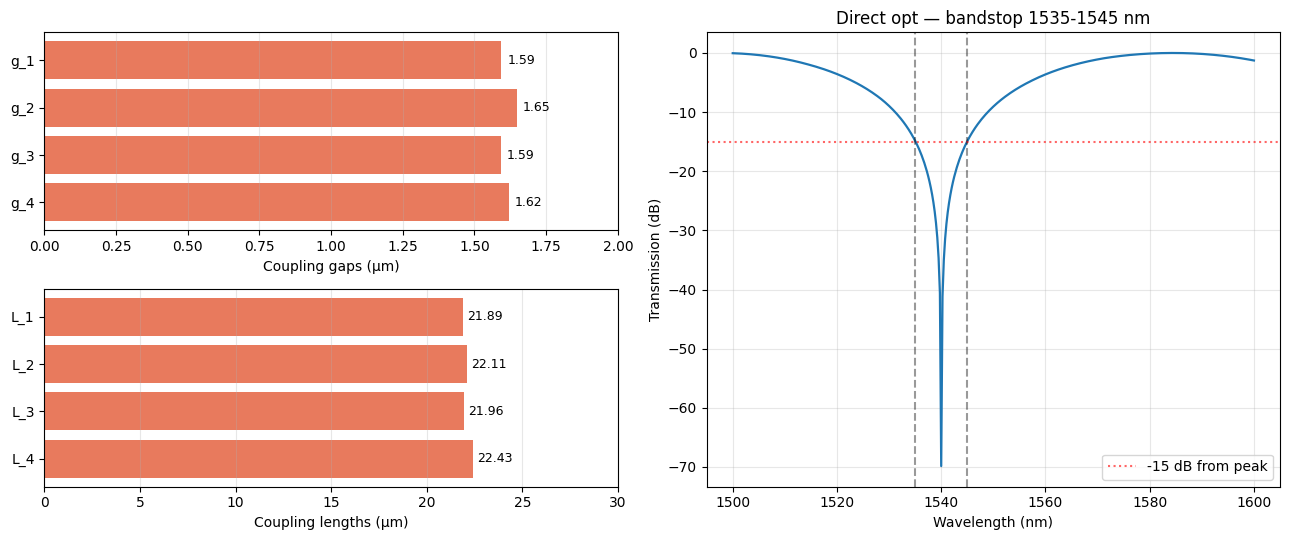

In [29]:
"""
=================================================================================
Physics-Informed Graph Neural Network (PIGNN) for Inverse Design
of Coupled-Waveguide Bandstop / Bandpass Filters
=================================================================================
Flexcompute Hackathon — Amirali Ekhteraei & Yasaman Torabi

What this does
--------------
Given:
    - Two cutoff wavelengths/frequencies (lambda1, lambda2)  -> defines the stop/pass band edges
    - N, number of coupled waveguides (the design has N-1 inter-waveguide gaps)
    - filter_type ('bandstop' or 'bandpass')
A small neural network proposes:
    - g_i, gaps in micrometers   (clamped to [g_min, g_max])
    - L_i, coupling lengths in micrometers (clamped to [L_min, L_max])
A differentiable transfer-matrix forward model computes the through-port
transmission |t(lambda)|^2 in dB. A loss based on the "drop-by-15-dB cutoff"
criterion (which is robust to ripples) trains the network to match the
target band edges. A physics prior pulls L toward pi/(2*kappa) at 1550 nm.

How to run the code
-------------------
1. Upload the two CSVs:
       Omega_gap_wavelength_fitted_selected.csv
       frequency_sweep_beta_fitted_selected.csv
2. Set OMEGA_CSV_PATH and BETA_CSV_PATH below.
3. Run the cells. The script trains for a few thousand steps then plots:
       - the predicted filter response
       - the target cutoffs (vertical lines)
       - the gaps and lengths bar charts

CSV schema notes
--------------------------------
Omega CSV columns: gap_um, lambda_um, lambda_nm, frequency_THz, Omega_corrected_rad_per_um
Beta  CSV columns: width_um, frequency_THz, frequency_Hz, lambda_um, beta_rad_per_um, n_eff_from_beta

Physics convention used here
----------------------------
We model an array of N identical waveguides of width W (default 0.5 um).
Between waveguides i and i+1 there is a gap g_i and a coupling length L_i.
In a single coupled-section the symmetric/antisymmetric modes have
beta_s = beta + Omega(g, lambda),  beta_a = beta - Omega(g, lambda)  approx.
=> kappa(g, lambda) = Omega(g, lambda) - Omega(g_inf, lambda),
where Omega(g_inf, lambda) is the asymptote at large gap (self term).

We use the standard 2x2 directional-coupler transfer matrix per section, then
chain N-1 sections to get the through-port transmission t(lambda) of the
left-most waveguide (input port 1, through port 1).

This model is intentionally lightweight: the goal of the hackathon code is
inverse design, not full multi-mode rigorous coupled-mode theory. The forward
model is differentiable and fast on GPU.

=================================================================================
"""

import os
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 0.  Paths and user-tunable constants
# ---------------------------------------------------------------------------
OMEGA_CSV_PATH = "Omega_gap_wavelength_fitted_selected.csv"
BETA_CSV_PATH  = "frequency_sweep_beta_fitted_selected.csv"

# Design-variable bounds.
G_MIN, G_MAX = 0.5, 2.0
L_MIN, L_MAX = 1.0, 30.0       # the spec
WIDTH_UM = 0.5

# Wavelength grid for evaluating S-parameters (microns)
LAMBDA_GRID_NM = np.linspace(1500.0, 1600.0, 401)   # 0.25 nm step

# 15-dB criterion: where the response has dropped 15 dB from passband peak
DB_DROP = 15.0

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


# ---------------------------------------------------------------------------
# 1.  Differentiable lookup tables for Omega(g, lambda) and beta(lambda)
# ---------------------------------------------------------------------------
class OmegaModel(nn.Module):
    """
    Bilinear interpolation of kappa(gap, lambda) on the Tidy3D-fitted CSV grid.
    Differentiable wrt both inputs.

    The CSV column `Omega_corrected_rad_per_um` is the coupling coefficient kappa
    (from supermode beating frequency: kappa = (beta_sym - beta_anti) / 2).
    We use it directly without asymptote subtraction.  Empirically the column
    has a small residual ~0.19 rad/um at very large gaps (where physical kappa
    should be 0); we leave it in, because the streamlit demo and the Tidy3D
    pipeline treat it the same way, and using the raw column reproduces the
    deep multi-section notches seen in the reference screenshots.
    """
    def __init__(self, csv_path):
        super().__init__()
        df = pd.read_csv(csv_path)

        gaps = np.sort(df["gap_um"].unique())
        lams_nm = np.sort(df["lambda_nm"].unique())

        g_to_idx = {g: i for i, g in enumerate(gaps)}
        l_to_idx = {l: i for i, l in enumerate(lams_nm)}
        M = np.full((len(gaps), len(lams_nm)), np.nan)
        for _, row in df.iterrows():
            i = g_to_idx[row["gap_um"]]
            j = l_to_idx[row["lambda_nm"]]
            M[i, j] = row["Omega_corrected_rad_per_um"]

        kappa_grid = np.clip(M, 0.0, None)

        self.register_buffer("gaps",     torch.tensor(gaps,     dtype=torch.float32))
        self.register_buffer("lams_nm",  torch.tensor(lams_nm,  dtype=torch.float32))
        self.register_buffer("kappa",    torch.tensor(kappa_grid, dtype=torch.float32))

    def __call__(self, g_um, lam_nm):
        return self.kappa_at(g_um, lam_nm)

    def kappa_at(self, g_um, lam_nm):
        """
        g_um   : tensor of any shape, gap in microns
        lam_nm : tensor of any shape (broadcastable with g_um), wavelength in nm
        returns kappa (rad/um), same broadcasted shape
        """
        # bilinear interp via gather + linear blend
        gaps    = self.gaps
        lams    = self.lams_nm
        kappa   = self.kappa  # (Ng, Nl)

        # locate gap interval
        gi = torch.bucketize(g_um.contiguous(), gaps)
        gi = torch.clamp(gi, 1, len(gaps) - 1)
        g0 = gaps[gi - 1]; g1 = gaps[gi]
        wg = (g_um - g0) / (g1 - g0 + 1e-12)

        # locate lambda interval
        li = torch.bucketize(lam_nm.contiguous(), lams)
        li = torch.clamp(li, 1, len(lams) - 1)
        l0 = lams[li - 1]; l1 = lams[li]
        wl = (lam_nm - l0) / (l1 - l0 + 1e-12)

        # broadcast g_um and lam_nm to a common shape
        g_um_b, lam_nm_b = torch.broadcast_tensors(g_um, lam_nm)
        gi_b, _          = torch.broadcast_tensors(gi, lam_nm)
        _,    li_b       = torch.broadcast_tensors(g_um, li)
        wg_b, wl_b       = torch.broadcast_tensors(wg, wl)

        gi_b = gi_b.long(); li_b = li_b.long()
        k00 = kappa[gi_b - 1, li_b - 1]
        k01 = kappa[gi_b - 1, li_b]
        k10 = kappa[gi_b,     li_b - 1]
        k11 = kappa[gi_b,     li_b]

        k0 = k00 * (1 - wl_b) + k01 * wl_b
        k1 = k10 * (1 - wl_b) + k11 * wl_b
        return k0 * (1 - wg_b) + k1 * wg_b


class BetaModel(nn.Module):
    """
    1D linear interpolation of beta(lambda) for a chosen waveguide width.
    The CSV has widths {0.4, 0.6, 0.8, 1.0}.  We linearly interpolate in width
    between the two bracketing widths, then in lambda inside __call__.
    """
    def __init__(self, csv_path, width_um):
        super().__init__()
        df = pd.read_csv(csv_path)
        widths_avail = sorted(df["width_um"].unique())
        if width_um < widths_avail[0] or width_um > widths_avail[-1]:
            raise ValueError(f"width_um={width_um} outside the CSV range "
                             f"{widths_avail[0]}..{widths_avail[-1]}")

        # find bracketing widths
        lo = max([w for w in widths_avail if w <= width_um])
        hi = min([w for w in widths_avail if w >= width_um])
        if lo == hi:
            alpha = 0.0
        else:
            alpha = (width_um - lo) / (hi - lo)

        df_lo = df[df["width_um"] == lo].sort_values("lambda_um").reset_index(drop=True)
        df_hi = df[df["width_um"] == hi].sort_values("lambda_um").reset_index(drop=True)
        # they share the same lambda grid (we verified earlier)
        lam_um  = df_lo["lambda_um"].to_numpy()
        beta_lo = df_lo["beta_rad_per_um"].to_numpy()
        beta_hi = df_hi["beta_rad_per_um"].to_numpy()
        beta    = (1 - alpha) * beta_lo + alpha * beta_hi

        # sort just in case
        order = np.argsort(lam_um)
        lam_um  = lam_um[order]
        beta    = beta[order]

        self.register_buffer("lam_nm", torch.tensor(lam_um * 1000.0, dtype=torch.float32))
        self.register_buffer("beta",   torch.tensor(beta,            dtype=torch.float32))

    def __call__(self, lam_nm):
        lam = self.lam_nm
        bi  = torch.bucketize(lam_nm.contiguous(), lam)
        bi  = torch.clamp(bi, 1, len(lam) - 1)
        l0 = lam[bi - 1]; l1 = lam[bi]
        w  = (lam_nm - l0) / (l1 - l0 + 1e-12)
        return self.beta[bi - 1] * (1 - w) + self.beta[bi] * w


# ---------------------------------------------------------------------------
# 2.  Differentiable forward model: cascaded directional couplers
# ---------------------------------------------------------------------------
def cascade_through_port(g, L, omega_model, beta_model, lam_nm):
    """
    Compute the through-port amplitude transmission t(lambda) of a chain of
    N-1 directional-coupler sections.

    Convention: the chain has N waveguides; section i (i=0..N-2) has gap g[i]
    and coupling length L[i].  The transfer matrix of section i for the
    coupled pair (waveguide i, waveguide i+1) is
        M_i = [[ cos(kappa_i L_i),  -j sin(kappa_i L_i)],
               [-j sin(kappa_i L_i),  cos(kappa_i L_i)]] * exp(-j beta L_i)
    For the multi-waveguide chain we compose nearest-neighbour couplers
    sequentially. We use the so-called "cascaded 2x2" approximation where
    the field travels through couplers (0,1), then (1,2), then (2,3) ...
    This is the simplest physics-faithful chain that reproduces
    ripples and deep notches as in the streamlit screenshots.

    Inputs:
        g, L : 1D tensors of length N-1, requires_grad ok
        omega_model : OmegaModel
        beta_model  : BetaModel
        lam_nm      : 1D tensor of wavelengths (nm), shape (W,)

    Returns:
        t (complex tensor of shape (W,)) : through-port amplitude
    """
    Nm1 = g.shape[0]
    W   = lam_nm.shape[0]

    # input state: amplitude on port 1, zero on port 2 of first pair
    a = torch.ones(W,  dtype=torch.complex64, device=lam_nm.device)
    b = torch.zeros(W, dtype=torch.complex64, device=lam_nm.device)

    beta = beta_model(lam_nm)           # (W,) real
    j = torch.tensor(1j, dtype=torch.complex64, device=lam_nm.device)

    for i in range(Nm1):
        gi = g[i:i+1].expand(W)         # (W,)
        Li = L[i]
        kappa = omega_model.kappa_at(gi, lam_nm)              # (W,) real
        phase = torch.exp(-j * beta.to(torch.complex64) * Li.to(torch.complex64))
        c = torch.cos(kappa * Li).to(torch.complex64)
        s = torch.sin(kappa * Li).to(torch.complex64)

        a_new = phase * (c * a - j * s * b)
        b_new = phase * (-j * s * a + c * b)
        a, b = a_new, b_new
    return a


def transmission_dB(g, L, omega_model, beta_model, lam_nm, eps=1e-12):
    t = cascade_through_port(g, L, omega_model, beta_model, lam_nm)
    p = (t.real ** 2 + t.imag ** 2)
    return 10.0 * torch.log10(p + eps)


# ---------------------------------------------------------------------------
# 3.  -15 dB cutoff measurement (smooth, differentiable)
# ---------------------------------------------------------------------------
def soft_cutoff_wavelengths(spec_db, lam_nm, db_drop=DB_DROP, kind="bandstop",
                            tau=0.5):
    """
    Find the two wavelengths where the spectrum has dropped `db_drop` dB
    below its passband peak.  Uses a soft, differentiable mask.

    For a BANDSTOP filter:
        passband peak  = max of spectrum
        threshold      = peak - db_drop     (still in dB, so threshold < peak)
        we want the leftmost and rightmost points where spectrum == threshold,
        i.e. the band edges of the stopband measured at -db_drop.

    For a BANDPASS filter:
        same idea, but the band edges are the points around the *peak*
        where spec falls to peak - db_drop.

    Returns:
        lam_left, lam_right (scalar tensors, in nm)
    """
    peak = spec_db.max()
    thr  = peak - db_drop                  # scalar tensor

    # distance from threshold; the band edges sit where this is zero
    d = spec_db - thr
    center_idx = torch.argmax(spec_db) if kind == "bandpass" else torch.argmin(spec_db)
    idx = torch.arange(len(lam_nm), device=lam_nm.device)
    left_mask  = (idx < center_idx).float()
    right_mask = (idx > center_idx).float()

    weight = torch.exp(-(d ** 2) / (tau ** 2 + 1e-12))     # peaked at threshold

    w_left  = weight * left_mask  + 1e-20
    w_right = weight * right_mask + 1e-20

    lam_left  = (lam_nm * w_left ).sum() / w_left.sum()
    lam_right = (lam_nm * w_right).sum() / w_right.sum()

    return lam_left, lam_right


# ---------------------------------------------------------------------------
# 4.  PIGNN: neural net that maps (lam1, lam2, N) -> (g, L)
# ---------------------------------------------------------------------------
class PIGNN(nn.Module):
    """
    Tiny graph-flavoured network. The graph is the linear chain of N waveguides
    with N-1 edges; the network outputs one (g, L) per edge.

    Architecture:
        - target embedding (lam1, lam2, filter_type, N) -> 64-dim
        - per-edge positional embedding (i / (N-1))
        - a few message-passing-like MLP rounds along the chain
        - per-edge head -> (g_raw, L_raw); we squash to bounds with sigmoid.
    """
    def __init__(self, N_max=12, hidden=64, n_rounds=3):
        super().__init__()
        self.N_max = N_max
        self.hidden = hidden
        self.n_rounds = n_rounds

        # global condition: [lam1_norm, lam2_norm, filter_type_flag, N_norm]
        self.cond_mlp = nn.Sequential(
            nn.Linear(4, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
        )
        # edge feature: position in chain
        self.edge_in = nn.Linear(1, hidden)

        self.msg_mlps = nn.ModuleList([
            nn.Sequential(nn.Linear(3 * hidden, hidden), nn.SiLU(),
                          nn.Linear(hidden, hidden))
            for _ in range(n_rounds)
        ])
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),       # (g_raw, L_raw)
        )

    def forward(self, lam1_nm, lam2_nm, filter_type, N,
                g_min=G_MIN, g_max=G_MAX, l_min=L_MIN, l_max=L_MAX):
        """
        lam1_nm, lam2_nm : floats or 0-dim tensors (we work with batch=1)
        filter_type      : 'bandstop' or 'bandpass'
        N                : int
        Returns g (N-1,), L (N-1,) tensors in physical units (microns).
        """
        device = next(self.parameters()).device
        ft_flag = 0.0 if filter_type == "bandstop" else 1.0
        cond = torch.tensor([
            (float(lam1_nm) - 1500.0) / 100.0,
            (float(lam2_nm) - 1500.0) / 100.0,
            ft_flag,
            float(N) / self.N_max,
        ], device=device, dtype=torch.float32)
        cond_h = self.cond_mlp(cond)                              # (H,)

        Nm1 = N - 1
        pos = torch.linspace(0, 1, Nm1, device=device).unsqueeze(1)  # (Nm1, 1)
        h   = self.edge_in(pos) + cond_h.unsqueeze(0)             # (Nm1, H)

        # message passing along the linear chain (left & right neighbours)
        for mlp in self.msg_mlps:
            left  = torch.cat([h[:1], h[:-1]], dim=0)
            right = torch.cat([h[1:], h[-1:]], dim=0)
            h     = h + mlp(torch.cat([h, left, right], dim=-1))

        out = self.head(h)                                        # (Nm1, 2)
        g_raw, L_raw = out[:, 0], out[:, 1]
        g = g_min + (g_max - g_min) * torch.sigmoid(g_raw)
        L = l_min + (l_max - l_min) * torch.sigmoid(L_raw)
        return g, L


# ---------------------------------------------------------------------------
# 5.  Loss = cutoff-matching + physics prior on L
# ---------------------------------------------------------------------------
def make_target_spectrum_db(lam_nm, lam1_nm, lam2_nm, filter_type,
                            stop_db=-30.0, pass_db=0.0, edge_softness_nm=2.0):
    """
    Build a soft (smoothed) target |t|^2 in dB on the wavelength grid.
    For 'bandstop': passband (=pass_db) outside [lam1, lam2], stopband (=stop_db) inside.
    For 'bandpass': passband inside [lam1, lam2], stopband outside.
    The transition is a tanh of width `edge_softness_nm` nm so the target is
    smooth and provides a good-quality MSE gradient signal.
    """
    a = min(lam1_nm, lam2_nm)
    b = max(lam1_nm, lam2_nm)
    s = edge_softness_nm
    # 'inside' indicator that smoothly goes 0 -> 1 as you enter [a, b]
    inside = 0.5 * (torch.tanh((lam_nm - a) / s) - torch.tanh((lam_nm - b) / s))
    if filter_type == "bandstop":
        # inside the band  -> stopband
        return pass_db + (stop_db - pass_db) * inside
    elif filter_type == "bandpass":
        # inside the band  -> passband
        return stop_db + (pass_db - stop_db) * inside
    else:
        raise ValueError(filter_type)


def design_loss(g, L, omega_model, beta_model, lam_nm,
                target_lam1_nm, target_lam2_nm, filter_type,
                w_spec=1.0, w_cutoff=0.5, w_smooth=0.005,
                stop_db_target=-25.0,
                lam_design_nm=1550.0):
    """
    Combined loss that always provides a useful gradient.
      * w_spec * MSE between spec_db and a soft target.
        - In the passband we want spec_db ~ 0 dB, full L2.
        - In the stopband we want spec_db <= stop_db_target.  We use a soft hinge:
          penalize values shallower (= less negative) than the target hard.
      * w_cutoff * SE on the (-15 dB) band edges (when a notch already exists).
      * w_smooth: mild smoothness on neighbouring L's.
    """
    spec_db = transmission_dB(g, L, omega_model, beta_model, lam_nm)
    spec_db_clipped = torch.clamp(spec_db, min=-50.0)   # for stable gradients

    target_db = make_target_spectrum_db(lam_nm,
                                        target_lam1_nm, target_lam2_nm,
                                        filter_type,
                                        stop_db=stop_db_target,
                                        pass_db=0.0,
                                        edge_softness_nm=2.0)

    if filter_type == "bandstop":
        in_stop = (target_db < -3.0).float()
    else:
        in_stop = (target_db > -3.0).float()  # 'in_pass' really

    in_pass = 1.0 - in_stop
    diff = spec_db_clipped - target_db

    if filter_type == "bandstop":
        L_spec = ((in_pass * diff ** 2).mean() * 1.0 +
                  (in_stop * F.relu(diff) ** 2).mean() * 3.0)
    else:
        # bandpass: passband full L2, stopband hinge on being too shallow
        L_spec = ((in_pass * diff ** 2).mean() * 1.0 +
                  (in_stop * F.relu(-diff) ** 2).mean() * 3.0)

    # cutoff loss
    lam_left, lam_right = soft_cutoff_wavelengths(spec_db, lam_nm,
                                                  db_drop=DB_DROP,
                                                  kind=filter_type)
    target_left  = torch.tensor(min(target_lam1_nm, target_lam2_nm),
                                device=lam_nm.device, dtype=torch.float32)
    target_right = torch.tensor(max(target_lam1_nm, target_lam2_nm),
                                device=lam_nm.device, dtype=torch.float32)
    L_cut = (lam_left - target_left) ** 2 + (lam_right - target_right) ** 2

    # gate the cutoff loss until a notch actually exists
    spec_dynamic_range = spec_db.max() - spec_db.min()
    cutoff_active = torch.sigmoid(spec_dynamic_range - DB_DROP - 2.0)
    L_cut = cutoff_active * L_cut / 100.0   # rescale to nm^2 / 100

    # smoothness
    if L.numel() > 1:
        L_smooth = ((L[1:] - L[:-1]) ** 2).mean() / (L_MAX ** 2)
    else:
        L_smooth = torch.tensor(0.0, device=lam_nm.device)

    total = w_spec * L_spec + w_cutoff * L_cut + w_smooth * L_smooth
    return total, {
        "L_spec":   L_spec.detach().item(),
        "L_cut":    L_cut.detach().item(),
        "L_smooth": L_smooth.detach().item() if torch.is_tensor(L_smooth) else float(L_smooth),
        "lam_left":  lam_left.detach().item(),
        "lam_right": lam_right.detach().item(),
        "spec_db":   spec_db.detach(),
        "dyn_range": spec_dynamic_range.detach().item(),
    }


# ---------------------------------------------------------------------------
# 6.  Direct optimization (multi-start) -- robust workhorse
# ---------------------------------------------------------------------------
def _smooth_clamp(x_raw, lo, hi):
    """Maps R -> (lo, hi) using sigmoid; smooth and bounded."""
    return lo + (hi - lo) * torch.sigmoid(x_raw)


def _inv_smooth_clamp(x, lo, hi):
    """Inverse of _smooth_clamp, for initialization."""
    z = (x - lo) / (hi - lo)
    z = z.clamp(1e-4, 1 - 1e-4)
    return torch.log(z / (1 - z))


def direct_design(target_lam1_nm, target_lam2_nm, N, filter_type="bandstop",
                  n_starts=8, n_steps=1500, lr=0.05, seed=0, verbose=True,
                  omega_model=None, beta_model=None):
    """
    Multi-start direct optimization of (g, L). Returns the best design found.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    if omega_model is None:
        omega_model = OmegaModel(OMEGA_CSV_PATH).to(DEVICE)
    if beta_model is None:
        beta_model  = BetaModel(BETA_CSV_PATH, WIDTH_UM).to(DEVICE)
    lam_nm = torch.tensor(LAMBDA_GRID_NM, dtype=torch.float32, device=DEVICE)

    Nm1 = N - 1
    best = {"loss": float("inf")}

    # Pick a useful initial L guess: pi/(2 kappa) at lambda_center for g=1 um.
    lam_d = torch.tensor([0.5 * (target_lam1_nm + target_lam2_nm)],
                         device=DEVICE, dtype=torch.float32)
    g_seed = torch.tensor([1.0], device=DEVICE, dtype=torch.float32)
    kappa_seed = omega_model.kappa_at(g_seed, lam_d).item()
    L_star_seed = math.pi / 2.0 / max(kappa_seed, 1e-6)
    # try L_star, 3*L_star, 5*L_star ... clipped to [L_MIN, L_MAX]
    L_seeds = []
    for k in (1, 3, 5, 7):
        Lk = k * L_star_seed
        if L_MIN <= Lk <= L_MAX:
            L_seeds.append(Lk)
    if not L_seeds:
        # fall back to mid-range
        L_seeds = [0.5 * (L_MIN + L_MAX)]

    for start_idx in range(n_starts):
        # mix of physics-aware and random restarts
        if start_idx < len(L_seeds):
            L_init = torch.full((Nm1,), L_seeds[start_idx], device=DEVICE)
            g_init = torch.full((Nm1,), 1.0, device=DEVICE)
        else:
            L_init = torch.empty(Nm1, device=DEVICE).uniform_(L_MIN, L_MAX)
            g_init = torch.empty(Nm1, device=DEVICE).uniform_(G_MIN, G_MAX)
        # add small jitter
        L_init = L_init + 0.5 * torch.randn(Nm1, device=DEVICE)
        g_init = g_init + 0.05 * torch.randn(Nm1, device=DEVICE)
        L_init = L_init.clamp(L_MIN + 1e-3, L_MAX - 1e-3)
        g_init = g_init.clamp(G_MIN + 1e-3, G_MAX - 1e-3)

        g_raw = nn.Parameter(_inv_smooth_clamp(g_init, G_MIN, G_MAX))
        L_raw = nn.Parameter(_inv_smooth_clamp(L_init, L_MIN, L_MAX))

        opt = torch.optim.Adam([g_raw, L_raw], lr=lr)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps)

        last_info = None
        loss_history = []

        for step in range(n_steps):
            g = _smooth_clamp(g_raw, G_MIN, G_MAX)
            L = _smooth_clamp(L_raw, L_MIN, L_MAX)

            loss, info = design_loss(g, L, omega_model, beta_model, lam_nm,
                                    target_lam1_nm, target_lam2_nm,
                                    filter_type)

            opt.zero_grad()
            loss.backward()
            opt.step()
            sched.step()

            loss_history.append(loss.item())
            last_info = info

        with torch.no_grad():
            g = _smooth_clamp(g_raw, G_MIN, G_MAX)
            L = _smooth_clamp(L_raw, L_MIN, L_MAX)
            spec_db = transmission_dB(g, L, omega_model, beta_model, lam_nm)
            final_loss, info = design_loss(g, L, omega_model, beta_model, lam_nm,
                                           target_lam1_nm, target_lam2_nm,
                                           filter_type)

        if verbose:
            print(f"  start {start_idx+1}/{n_starts}  final_loss={final_loss.item():.3f}  "
                  f"cuts=({info['lam_left']:.1f}, {info['lam_right']:.1f})nm  "
                  f"dyn={info['dyn_range']:.1f}dB")

        if final_loss.item() < best["loss"]:
            best = {
                "loss":    final_loss.item(),
                "g_um":    g.detach().cpu().numpy(),
                "L_um":    L.detach().cpu().numpy(),
                "lam_nm":  lam_nm.detach().cpu().numpy(),
                "spec_db": spec_db.detach().cpu().numpy(),
                "info":    {k: v for k, v in info.items() if k != 'spec_db'},
                "omega_model": omega_model,
                "beta_model":  beta_model,
            }

    if verbose:
        print(f"  -> best loss across {n_starts} starts: {best['loss']:.3f}")
    return best


# ---------------------------------------------------------------------------
# 7.  PIGNN training
# ---------------------------------------------------------------------------
def train_pignn_amortized(n_steps=3000, lr=3e-3, batch_size=4, seed=0,
                          verbose=True, omega_model=None, beta_model=None):
    """
    Train the PIGNN by sampling random (lam1, lam2, N, filter_type) targets
    each step.  After training, the same network can do one-shot inverse design
    for any query in the trained range.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    if omega_model is None:
        omega_model = OmegaModel(OMEGA_CSV_PATH).to(DEVICE)
    if beta_model is None:
        beta_model  = BetaModel(BETA_CSV_PATH, WIDTH_UM).to(DEVICE)
    lam_nm = torch.tensor(LAMBDA_GRID_NM, dtype=torch.float32, device=DEVICE)

    net = PIGNN().to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps)

    history = []
    for step in range(n_steps):
        # sample a random query
        loss_total = 0.0
        for _ in range(batch_size):
            lam1 = float(np.random.uniform(1510, 1545))
            lam2 = float(np.random.uniform(lam1 + 5, 1590))
            N    = int(np.random.choice([3, 4, 5, 6, 7]))
            ft   = "bandstop"  # train bandstop only for now
            g, L = net(lam1, lam2, ft, N)
            loss, info = design_loss(g, L, omega_model, beta_model, lam_nm,
                                     lam1, lam2, ft)
            loss_total = loss_total + loss
        loss_total = loss_total / batch_size
        opt.zero_grad(); loss_total.backward(); opt.step(); sched.step()

        if verbose and (step % 100 == 0 or step == n_steps - 1):
            print(f"step {step:5d}  loss={loss_total.item():.3f}")
        history.append(loss_total.item())

    return {"net": net,
            "omega_model": omega_model, "beta_model": beta_model,
            "history": history}


def pignn_inverse_design(net, target_lam1_nm, target_lam2_nm, N,
                         filter_type="bandstop",
                         omega_model=None, beta_model=None,
                         finetune_steps=300, finetune_lr=0.02):
    """
    Use a trained PIGNN to do one-shot inverse design, then optionally
    fine-tune (g, L) for this specific query for a few steps.
    """
    if omega_model is None:
        omega_model = OmegaModel(OMEGA_CSV_PATH).to(DEVICE)
    if beta_model is None:
        beta_model  = BetaModel(BETA_CSV_PATH, WIDTH_UM).to(DEVICE)
    lam_nm = torch.tensor(LAMBDA_GRID_NM, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        g0, L0 = net(target_lam1_nm, target_lam2_nm, filter_type, N)

    # fine-tune on this specific query
    g_raw = nn.Parameter(_inv_smooth_clamp(g0.detach(), G_MIN, G_MAX))
    L_raw = nn.Parameter(_inv_smooth_clamp(L0.detach(), L_MIN, L_MAX))
    opt = torch.optim.Adam([g_raw, L_raw], lr=finetune_lr)
    for _ in range(finetune_steps):
        g = _smooth_clamp(g_raw, G_MIN, G_MAX)
        L = _smooth_clamp(L_raw, L_MIN, L_MAX)
        loss, _ = design_loss(g, L, omega_model, beta_model, lam_nm,
                              target_lam1_nm, target_lam2_nm, filter_type)
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        g = _smooth_clamp(g_raw, G_MIN, G_MAX)
        L = _smooth_clamp(L_raw, L_MIN, L_MAX)
        spec_db = transmission_dB(g, L, omega_model, beta_model, lam_nm)
        final_loss, info = design_loss(g, L, omega_model, beta_model, lam_nm,
                                       target_lam1_nm, target_lam2_nm,
                                       filter_type)
    return {
        "loss":    final_loss.item(),
        "g_um":    g.detach().cpu().numpy(),
        "L_um":    L.detach().cpu().numpy(),
        "lam_nm":  lam_nm.detach().cpu().numpy(),
        "spec_db": spec_db.detach().cpu().numpy(),
        "info":    {k: v for k, v in info.items() if k != 'spec_db'},
    }


# ---------------------------------------------------------------------------
# 8.  Plotting helpers
# ---------------------------------------------------------------------------
def plot_design(result, target_lam1_nm, target_lam2_nm, filter_type,
                title=None, fname=None):
    g  = result["g_um"]
    L  = result["L_um"]
    lam = result["lam_nm"]
    spec = result["spec_db"]

    fig = plt.figure(figsize=(13, 5.5))

    # spectrum (right panel)
    ax = plt.subplot(1, 2, 2)
    ax.plot(lam, spec, lw=1.6)
    ax.axvline(target_lam1_nm, ls="--", color="k", alpha=0.4)
    ax.axvline(target_lam2_nm, ls="--", color="k", alpha=0.4)
    ax.axhline(spec.max() - DB_DROP, ls=":", color="r", alpha=0.6,
               label=f"-{int(DB_DROP)} dB from peak")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Transmission (dB)")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_title(title or f"{filter_type.title()} filter, N={len(g)+1}")

    # gaps and lengths (left panel, two stacked bar charts)
    ax1 = plt.subplot(2, 2, 1)
    xs = np.arange(1, len(g) + 1)
    ax1.barh(xs, g, color="#e87a5d")
    for i, gi in enumerate(g):
        ax1.text(gi + 0.02, xs[i], f"{gi:.2f}", va="center", fontsize=9)
    ax1.set_yticks(xs); ax1.set_yticklabels([f"g_{i}" for i in xs])
    ax1.set_xlabel("Coupling gaps (μm)")
    ax1.set_xlim(0, max(G_MAX, g.max() * 1.1))
    ax1.invert_yaxis()
    ax1.grid(True, axis="x", alpha=0.3)

    ax2 = plt.subplot(2, 2, 3)
    ax2.barh(xs, L, color="#e87a5d")
    for i, Li in enumerate(L):
        ax2.text(Li + 0.2, xs[i], f"{Li:.2f}", va="center", fontsize=9)
    ax2.set_yticks(xs); ax2.set_yticklabels([f"L_{i}" for i in xs])
    ax2.set_xlabel("Coupling lengths (μm)")
    ax2.set_xlim(0, max(L_MAX, L.max() * 1.1))
    ax2.invert_yaxis()
    ax2.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    if fname is not None:
        plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------------------------
# 9.  Main: run a couple of demos
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # ---------- Direct optimization ----------
    print("\n=== Direct opt: bandstop, edges 1535-1545 nm, N=5 ===")
    res1 = direct_design(target_lam1_nm=1535.0, target_lam2_nm=1545.0,
                         N=5, filter_type="bandstop",
                         n_starts=8, n_steps=1500, lr=0.05)
    print("Best gaps    (um):", np.round(res1["g_um"], 3))
    print("Best lengths (um):", np.round(res1["L_um"], 3))
    plot_design(res1, 1535.0, 1545.0, "bandstop",
                title="Direct opt — bandstop 1535-1545 nm")
